S1 (No stimulation):  14 trials  |  8 correct  |  6 incorrect
S2 (Targeted stim):  14 trials  |  6 correct  |  8 incorrect
S3 (Targeted stim):  14 trials  |  8 correct  |  6 incorrect
S4 (Stim throughout):  14 trials  |  8 correct  |  6 incorrect


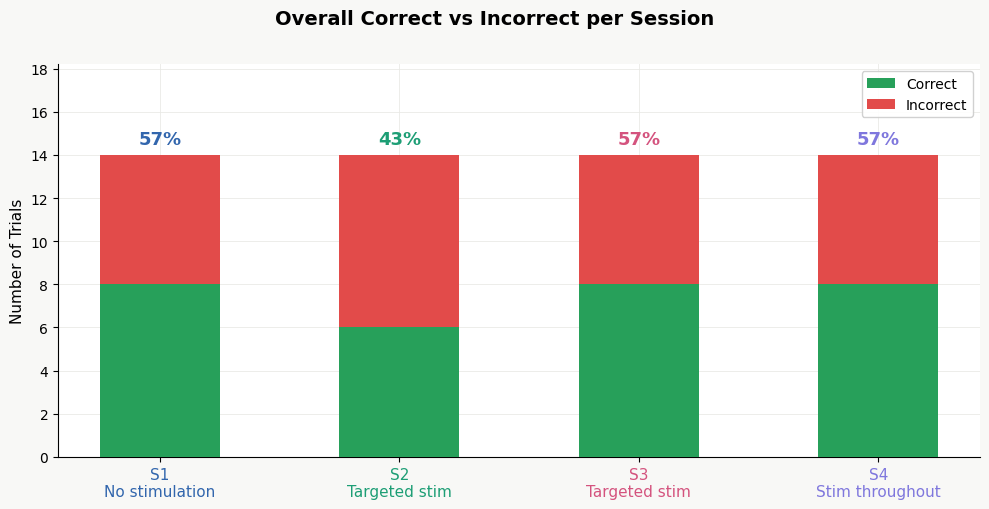

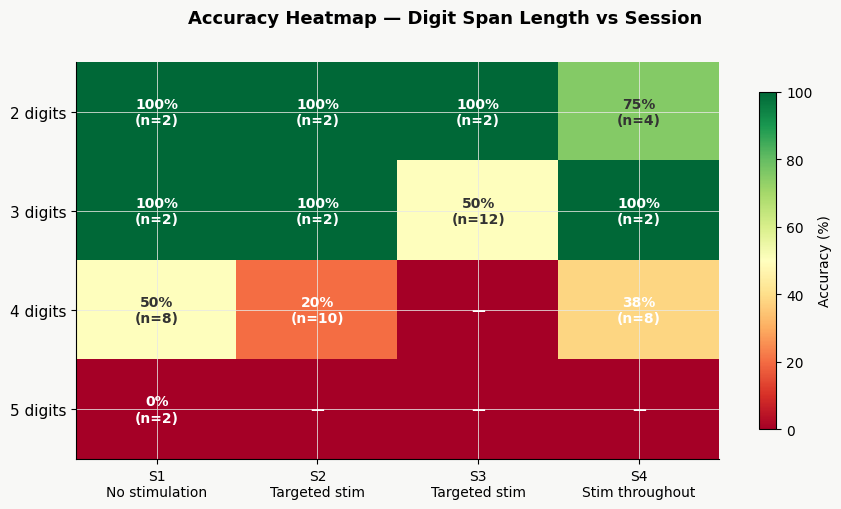

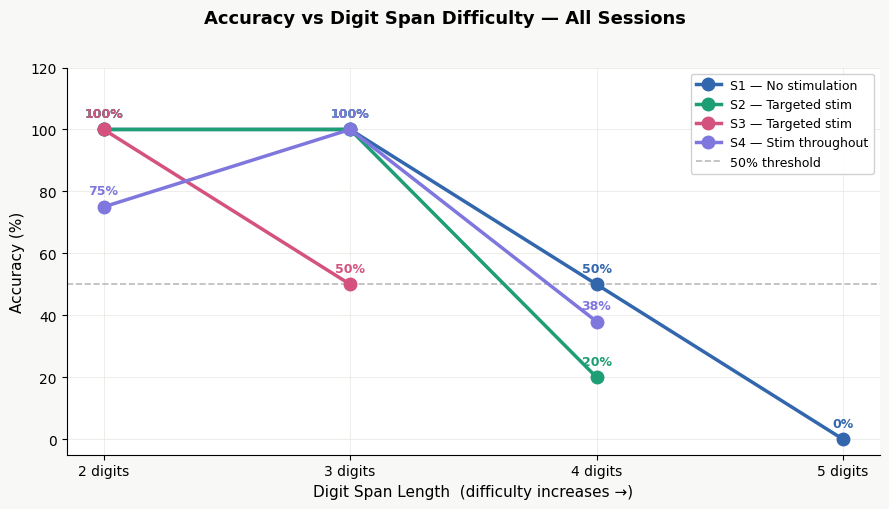

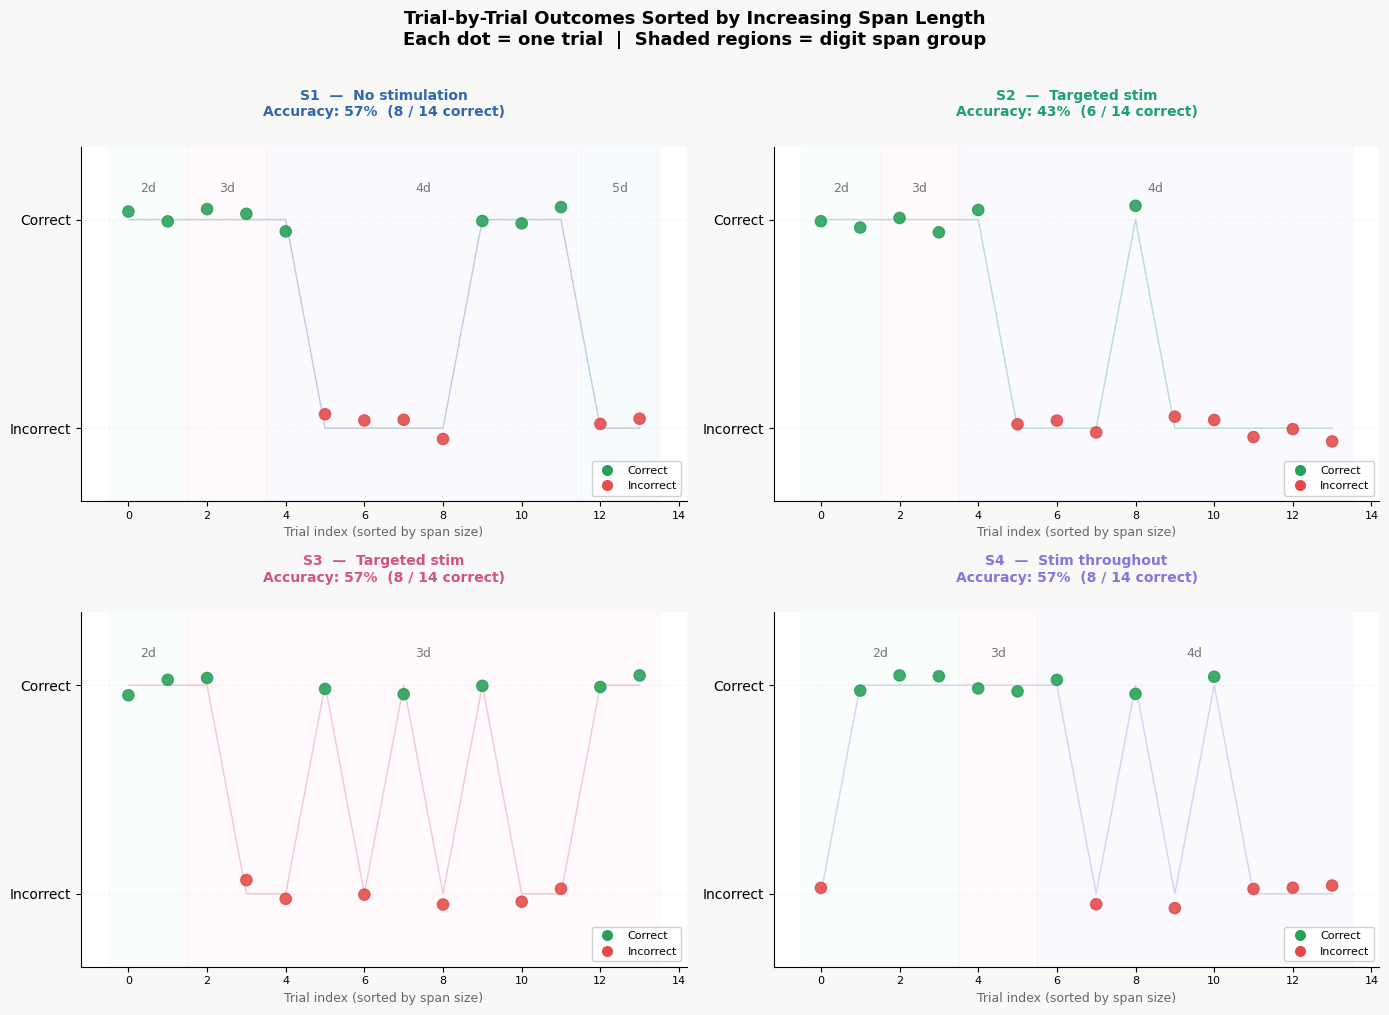

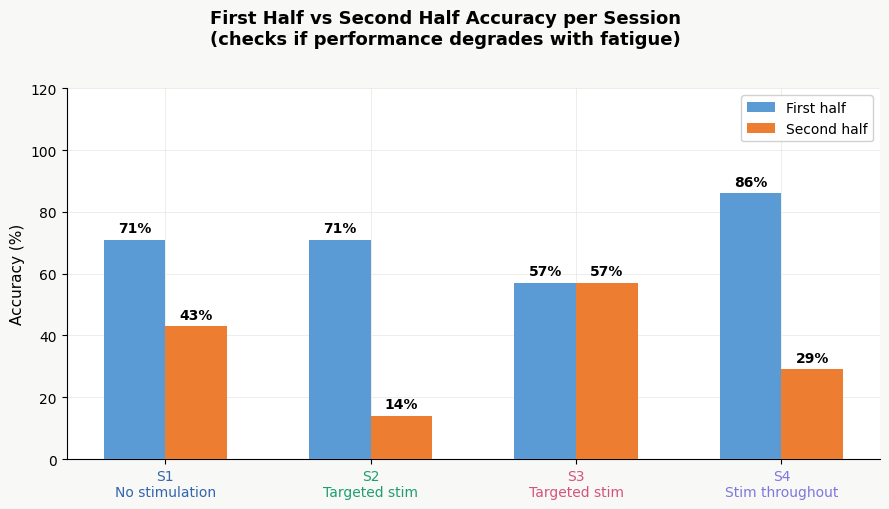

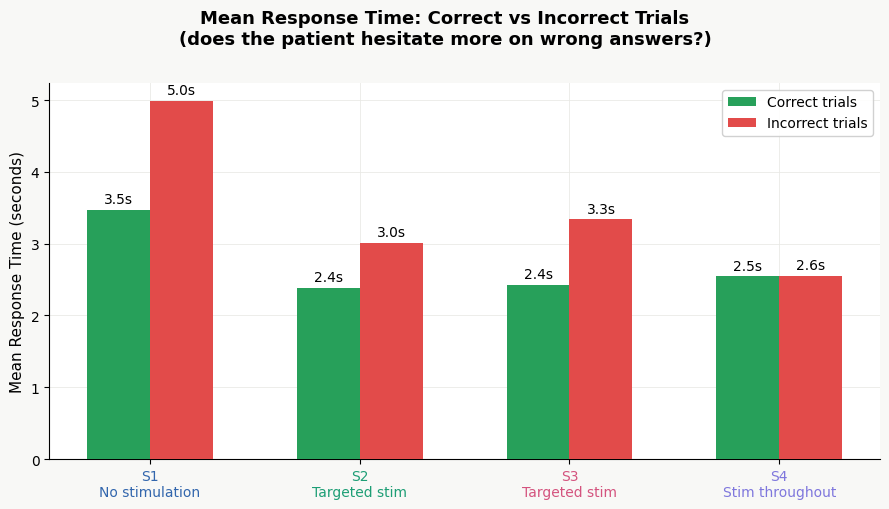

In [2]:
# ============================================================
# CELL 1 — Imports & Config
# ============================================================
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e8e4",
    "grid.linewidth": 0.7,
    "figure.facecolor": "#f8f8f6",
    "axes.facecolor": "#ffffff",
})

BASE = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2"

SESSIONS = [
    {"label": "S1", "stim": "No stimulation",  "color": "#3266ad",
     "csv": f"{BASE}\\DigitSpanBackward v3.3-6-1-Scores.csv"},
    {"label": "S2", "stim": "Targeted stim",   "color": "#1D9E75",
     "csv": f"{BASE}\\DigitSpanBackward v3.3-6-2-Scores.csv"},
    {"label": "S3", "stim": "Targeted stim",   "color": "#D4537E",
     "csv": f"{BASE}\\DigitSpanBackward v3.3-6-3-Scores.csv"},
    {"label": "S4", "stim": "Stim throughout", "color": "#7F77DD",
     "csv": f"{BASE}\\DigitSpanBackward v3.3-6-4-Scores.csv"},
]

COL_CORRECT   = "#27a05a"
COL_INCORRECT = "#E24B4A"


# ============================================================
# CELL 2 — Load & preprocess all sessions
# ============================================================
import os

def load_session(path, label):
    if not os.path.exists(path):
        print(f"  ⚠  Not found: {path}  →  {label} skipped")
        return None
    df_raw = pd.read_csv(path, header=None)
    cols   = df_raw.iloc[1].tolist()
    df     = pd.DataFrame(df_raw.values[2:], columns=cols)
    for c in ["Block","Trial","CurrentSpanSize[Trial]",
              "CollectResponse.ACC","CollectResponse.RESP",
              "CorrectResp","CollectResponse.RT"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["CollectResponse.ACC"])
    trial = (
        df.groupby(["Block","Trial"])
        .agg(
            span  = ("CurrentSpanSize[Trial]", "first"),
            acc   = ("CollectResponse.ACC",    "first"),
            resp  = ("CollectResponse.RESP",   "first"),
            cresp = ("CorrectResp",            "first"),
            rt    = ("CollectResponse.RT",     "first"),
        )
        .reset_index()
        .sort_values(["Block","Trial"])
        .reset_index(drop=True)
    )
    return trial

for s in SESSIONS:
    t = load_session(s["csv"], s["label"])
    if t is not None:
        s["df"] = t
        n   = len(t)
        cor = int(t["acc"].sum())
        print(f"{s['label']} ({s['stim']}):  {n} trials  |  {cor} correct  |  {n - cor} incorrect")

loaded     = [s for s in SESSIONS if "df" in s]
dfs        = [s["df"]    for s in loaded]
labels     = [s["label"] for s in loaded]
stims      = [s["stim"]  for s in loaded]
colors     = [s["color"] for s in loaded]
totals     = [len(d)              for d in dfs]
corrects   = [int(d["acc"].sum()) for d in dfs]
wrongs     = [t - c for t, c in zip(totals, corrects)]
accs       = [round(c / t * 100) for c, t in zip(corrects, totals)]
all_spans  = sorted(set().union(*[set(d["span"].dropna().astype(int)) for d in dfs]))
n_sess     = len(loaded)

def acc_pct(df):
    return round(df["acc"].sum() / len(df) * 100) if len(df) else 0

def span_acc(df, sp):
    sub = df[df["span"] == sp]
    return (acc_pct(sub), len(sub))


# ============================================================
# CELL 3 — Plot 1: Overall correct vs incorrect per session
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Overall Correct vs Incorrect per Session",
             fontsize=14, fontweight="bold", y=1.01)

x = np.arange(n_sess)
w = 0.5

bars_c = ax.bar(x, corrects, w, label="Correct",   color=COL_CORRECT,   zorder=3)
bars_w = ax.bar(x, wrongs,   w, bottom=corrects,   label="Incorrect",   color=COL_INCORRECT, zorder=3)

for i, (xi, c, wr, acc) in enumerate(zip(x, corrects, wrongs, accs)):
    ax.text(xi, c + wr + 0.3, f"{acc}%",
            ha="center", va="bottom", fontsize=13,
            fontweight="bold", color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels([f"{s['label']}\n{s['stim']}" for s in loaded], fontsize=11)
for tick, col in zip(ax.get_xticklabels(), colors):
    tick.set_color(col)

ax.set_ylabel("Number of Trials", fontsize=11)
ax.set_ylim(0, max(totals) * 1.3)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()


# ============================================================
# CELL 4 — Plot 2: Accuracy heatmap by span length × session
# ============================================================
heat_data = np.zeros((len(all_spans), n_sess))
heat_ann  = [["" for _ in range(n_sess)] for _ in all_spans]

for si, d in enumerate(dfs):
    for spi, sp in enumerate(all_spans):
        a, n = span_acc(d, sp)
        heat_data[spi, si] = a
        heat_ann[spi][si]  = f"{a}%\n(n={n})" if n else "—"

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Accuracy Heatmap — Digit Span Length vs Session",
             fontsize=13, fontweight="bold", y=1.01)

im = ax.imshow(heat_data, cmap="RdYlGn", vmin=0, vmax=100,
               aspect="auto", interpolation="nearest")
ax.set_xticks(range(n_sess))
ax.set_xticklabels([f"{s['label']}\n{s['stim']}" for s in loaded], fontsize=10)
ax.set_yticks(range(len(all_spans)))
ax.set_yticklabels([f"{sp} digit{'s' if sp > 1 else ''}" for sp in all_spans], fontsize=11)

for sp_i in range(len(all_spans)):
    for si in range(n_sess):
        val = heat_data[sp_i, si]
        col = "white" if val < 40 or val > 80 else "#333"
        ax.text(si, sp_i, heat_ann[sp_i][si],
                ha="center", va="center", fontsize=10,
                color=col, fontweight="bold")

plt.colorbar(im, ax=ax, label="Accuracy (%)", shrink=0.85)
plt.tight_layout()
plt.show()


# ============================================================
# CELL 5 — Plot 3: Accuracy vs span length — all sessions overlaid
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Accuracy vs Digit Span Difficulty — All Sessions",
             fontsize=13, fontweight="bold", y=1.01)

for i, (s, d) in enumerate(zip(loaded, dfs)):
    pts = [span_acc(d, sp)[0] if span_acc(d, sp)[1] else np.nan for sp in all_spans]
    ax.plot(all_spans, pts, marker="o", markersize=9,
            linewidth=2.5, color=s["color"],
            label=f"{s['label']} — {s['stim']}", zorder=3)
    for sp, pt in zip(all_spans, pts):
        if not np.isnan(pt):
            ax.annotate(f"{int(pt)}%", (sp, pt),
                        textcoords="offset points", xytext=(0, 9),
                        ha="center", fontsize=9,
                        color=s["color"], fontweight="bold")

ax.axhline(50, color="#bbb", linestyle="--", linewidth=1.2, label="50% threshold")
ax.set_xticks(all_spans)
ax.set_xticklabels([f"{sp} digit{'s' if sp > 1 else ''}" for sp in all_spans], fontsize=10)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_xlabel("Digit Span Length  (difficulty increases →)", fontsize=11)
ax.set_ylim(-5, 120)
ax.legend(fontsize=9, framealpha=0.9, loc="upper right")
plt.tight_layout()
plt.show()


# ============================================================
# CELL 6 — Plot 4: Trial-by-trial line charts (4 panels)
#           Trials sorted by span size — shows outcome as
#           difficulty ramps up within each session
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Trial-by-Trial Outcomes Sorted by Increasing Span Length\n"
    "Each dot = one trial  |  Shaded regions = digit span group",
    fontsize=13, fontweight="bold", y=1.01
)

bg_palette = ["#e8f4fd", "#fef9ed", "#edfaf3", "#fdedf1", "#f0edfb"]
rng = np.random.default_rng(42)

for i, s in enumerate(loaded):
    ax = axes.flatten()[i]
    d  = dfs[i].copy().sort_values(["span", "Block", "Trial"]).reset_index(drop=True)

    acc_seq   = d["acc"].values.astype(int)
    spans_seq = d["span"].values.astype(int)
    dot_colors = [COL_CORRECT if a == 1 else COL_INCORRECT for a in acc_seq]

    # slight vertical jitter so dots don't all sit on 0 or 1
    jitter = rng.uniform(-0.07, 0.07, len(acc_seq))

    ax.scatter(range(len(d)), acc_seq + jitter,
               c=dot_colors, s=65, zorder=4, alpha=0.88)
    ax.plot(range(len(d)), acc_seq,
            color=s["color"], linewidth=1.0, alpha=0.3, zorder=2)

    # shade + label each span group
    span_changes = np.where(np.diff(spans_seq, prepend=-1) != 0)[0]
    span_changes = np.append(span_changes, len(d))

    for j in range(len(span_changes) - 1):
        start = span_changes[j]
        end   = span_changes[j + 1]
        sp    = spans_seq[start]
        col   = bg_palette[sp % len(bg_palette)]
        ax.axvspan(start - 0.5, end - 0.5, alpha=0.3, color=col, zorder=1)
        ax.text((start + end) / 2 - 0.5, 1.12,
                f"{sp}d", ha="center", fontsize=9,
                color="#777", va="bottom", fontweight="500")

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Incorrect", "Correct"], fontsize=10)
    ax.set_ylim(-0.35, 1.35)
    ax.set_xlabel("Trial index (sorted by span size)", fontsize=9, color="#666")
    ax.set_title(
        f"{s['label']}  —  {s['stim']}\n"
        f"Accuracy: {accs[i]}%  ({corrects[i]} / {totals[i]} correct)",
        fontsize=10, fontweight="bold", color=s["color"], pad=22
    )
    ax.tick_params(axis="x", labelsize=8)
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.45)

    legend_els = [
        Line2D([0],[0], marker="o", color="w",
               markerfacecolor=COL_CORRECT,   markersize=9, label="Correct"),
        Line2D([0],[0], marker="o", color="w",
               markerfacecolor=COL_INCORRECT, markersize=9, label="Incorrect"),
    ]
    ax.legend(handles=legend_els, loc="lower right", fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()


# ============================================================
# CELL 7 — Plot 5: First-half vs second-half accuracy per session
# ============================================================
first_acc, second_acc = [], []
for d in dfs:
    mid = len(d) // 2
    first_acc.append(acc_pct(d.iloc[:mid]))
    second_acc.append(acc_pct(d.iloc[mid:]))

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("First Half vs Second Half Accuracy per Session\n"
             "(checks if performance degrades with fatigue)",
             fontsize=13, fontweight="bold", y=1.01)

x  = np.arange(n_sess)
w3 = 0.3
b1 = ax.bar(x - w3/2, first_acc,  w3, color="#5B9BD5", label="First half",  zorder=3)
b2 = ax.bar(x + w3/2, second_acc, w3, color="#ED7D31", label="Second half", zorder=3)

for bar, val in list(zip(b1, first_acc)) + list(zip(b2, second_acc)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f"{val}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"{s['label']}\n{s['stim']}" for s in loaded], fontsize=10)
for tick, col in zip(ax.get_xticklabels(), colors):
    tick.set_color(col)

ax.set_ylim(0, 120)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()


# ============================================================
# CELL 8 — Plot 6: Mean RT — correct vs incorrect trials
# ============================================================
mean_rt_c, mean_rt_i = [], []
for d in dfs:
    rc = d[d["acc"] == 1]["rt"].dropna()
    ri = d[d["acc"] == 0]["rt"].dropna()
    mean_rt_c.append(rc.mean() / 1000 if len(rc) else np.nan)
    mean_rt_i.append(ri.mean() / 1000 if len(ri) else np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Mean Response Time: Correct vs Incorrect Trials\n"
             "(does the patient hesitate more on wrong answers?)",
             fontsize=13, fontweight="bold", y=1.01)

x  = np.arange(n_sess)
w4 = 0.3
b1 = ax.bar(x - w4/2, mean_rt_c, w4, color=COL_CORRECT,   label="Correct trials",   zorder=3)
b2 = ax.bar(x + w4/2, mean_rt_i, w4, color=COL_INCORRECT, label="Incorrect trials", zorder=3)

for bar, val in list(zip(b1, mean_rt_c)) + list(zip(b2, mean_rt_i)):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
                f"{val:.1f}s", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([f"{s['label']}\n{s['stim']}" for s in loaded], fontsize=10)
for tick, col in zip(ax.get_xticklabels(), colors):
    tick.set_color(col)

ax.set_ylabel("Mean Response Time (seconds)", fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

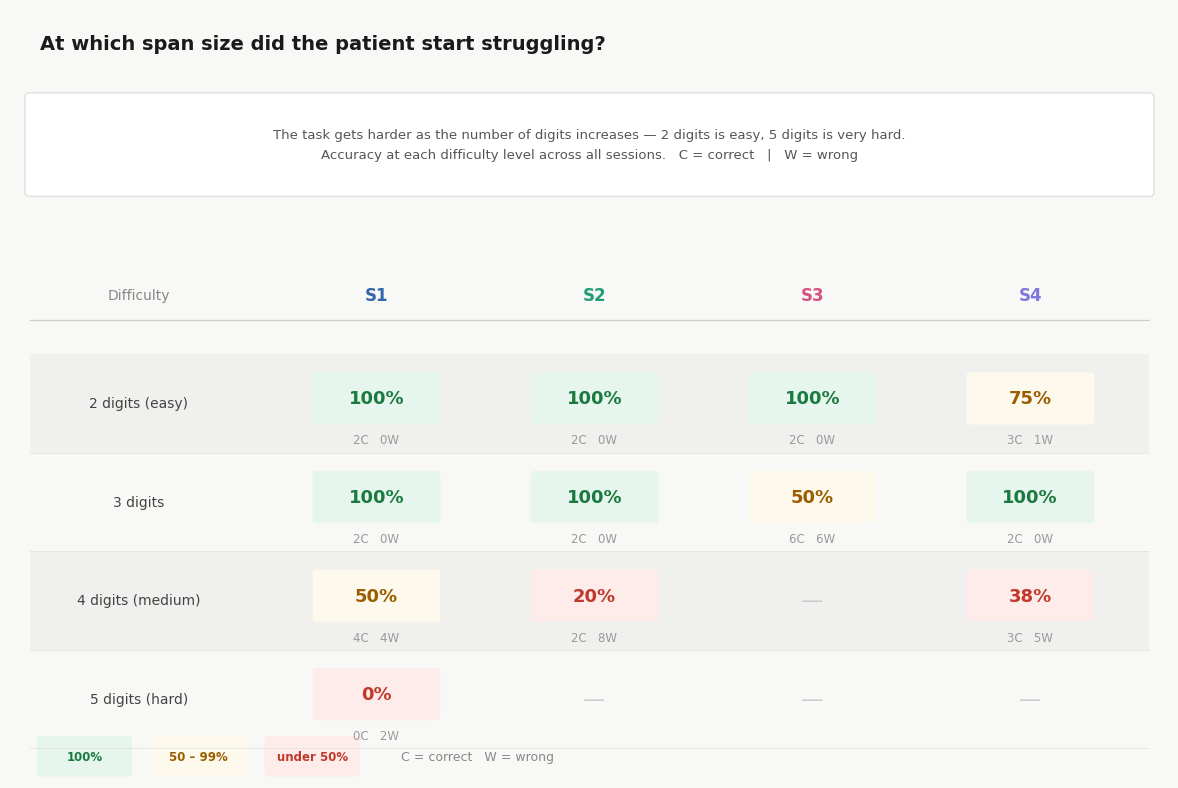

In [7]:
# ============================================================
# CELL — Span Difficulty Table (fixed layout)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

span_labels = {2: "2 digits (easy)", 3: "3 digits", 4: "4 digits (medium)", 5: "5 digits (hard)"}
all_spans   = sorted(span_labels.keys())

# ── collect stats ─────────────────────────────────────────────
table = {}
for si, d in enumerate(dfs):
    for sp in all_spans:
        sub   = d[d["span"] == sp]
        n     = len(sub)
        n_cor = int(sub["acc"].sum())
        n_inc = n - n_cor
        acc   = round(n_cor / n * 100) if n else None
        table[(sp, si)] = (acc, n_cor, n_inc, n)

def badge_color(acc):
    if acc is None:  return None, None
    if acc == 100:   return "#e6f5ed", "#1a7a3f"
    if acc >= 50:    return "#fef9ed", "#9a5d00"
    return "#fdecea", "#c0392b"

# ── figure using a real data coordinate system ────────────────
# rows: one per span (4 rows) + header + title + subtitle + footer
# cols: difficulty label + 4 sessions

N_ROWS   = len(all_spans)   # 4
N_COLS   = n_sess            # 4
ROW_H    = 1.0               # height per data row
COL_W    = 2.2               # width per session column
LABEL_W  = 2.6               # width of difficulty label column
PAD      = 0.3

total_w  = LABEL_W + N_COLS * COL_W + PAD
total_h  = N_ROWS * ROW_H + 3.8     # rows + header + title + subtitle + footer

fig, ax = plt.subplots(figsize=(total_w, total_h))
fig.patch.set_facecolor("#f8f8f6")
ax.set_facecolor("#f8f8f6")
ax.set_xlim(0, total_w)
ax.set_ylim(0, total_h)
ax.axis("off")

# helper: x center for session column si
def col_cx(si):
    return LABEL_W + (si + 0.5) * COL_W

# helper: y center for data row ri (row 0 = top)
def row_cy(ri):
    return total_h - 3.5 - (ri + 0.5) * ROW_H

# ── title ─────────────────────────────────────────────────────
ax.text(0.3, total_h - 0.35,
        "At which span size did the patient start struggling?",
        fontsize=14, fontweight="bold", va="center", color="#1a1a1a")

# ── subtitle box ──────────────────────────────────────────────
sub_y0 = total_h - 1.85
sub_h  = 0.95
rect = FancyBboxPatch((0.2, sub_y0), total_w - 0.4, sub_h,
                       boxstyle="round,pad=0.05",
                       linewidth=1, edgecolor="#e0e0dc",
                       facecolor="#ffffff", zorder=1)
ax.add_patch(rect)
ax.text(total_w / 2, sub_y0 + sub_h / 2,
        "The task gets harder as the number of digits increases — "
        "2 digits is easy, 5 digits is very hard.\n"
        "Accuracy at each difficulty level across all sessions.   "
        "C = correct   |   W = wrong",
        fontsize=9.5, va="center", ha="center",
        color="#555", linespacing=1.7, zorder=2)

# ── column headers ────────────────────────────────────────────
header_y = total_h - 2.9
ax.text(LABEL_W / 2, header_y, "Difficulty",
        fontsize=10, fontweight="500", color="#888",
        va="center", ha="center")

for si, s in enumerate(loaded):
    ax.text(col_cx(si), header_y, s["label"],
            fontsize=12, fontweight="700", color=s["color"],
            va="center", ha="center")

# header separator line
sep_y = total_h - 3.15
ax.plot([0.2, total_w - 0.2], [sep_y, sep_y],
        color="#d0d0cc", linewidth=0.9)

# ── rows ──────────────────────────────────────────────────────
BADGE_W = COL_W * 0.55
BADGE_H = ROW_H * 0.45

for ri, sp in enumerate(all_spans):
    cy = row_cy(ri)
    y0 = cy - ROW_H / 2

    # alternating row background
    if ri % 2 == 0:
        bg = FancyBboxPatch((0.2, y0), total_w - 0.4, ROW_H,
                             boxstyle="square,pad=0",
                             linewidth=0, facecolor="#f0f0ee", zorder=0)
        ax.add_patch(bg)

    # row bottom separator
    ax.plot([0.2, total_w - 0.2], [y0, y0],
            color="#e4e4e0", linewidth=0.6)

    # difficulty label
    ax.text(LABEL_W / 2, cy, span_labels[sp],
            fontsize=10, color="#444",
            va="center", ha="center")

    # session cells
    for si in range(n_sess):
        acc, n_cor, n_inc, n = table[(sp, si)]
        cx = col_cx(si)

        if acc is None or n == 0:
            ax.text(cx, cy, "—", fontsize=16, color="#ccc",
                    va="center", ha="center")
            continue

        bg_c, fg_c = badge_color(acc)

        # badge
        badge = FancyBboxPatch(
            (cx - BADGE_W / 2, cy - BADGE_H / 2 + 0.05),
            BADGE_W, BADGE_H,
            boxstyle="round,pad=0.04",
            linewidth=0, facecolor=bg_c, zorder=2
        )
        ax.add_patch(badge)

        # accuracy % inside badge
        ax.text(cx, cy + 0.05, f"{acc}%",
                fontsize=13, fontweight="bold", color=fg_c,
                va="center", ha="center", zorder=3)

        # C / W count below badge
        ax.text(cx, cy - BADGE_H / 2 - 0.08,
                f"{n_cor}C   {n_inc}W",
                fontsize=8.5, color="#999",
                va="top", ha="center")

# ── legend footer ─────────────────────────────────────────────
legend_items = [
    ("#e6f5ed", "#1a7a3f", "100%"),
    ("#fef9ed", "#9a5d00", "50 – 99%"),
    ("#fdecea", "#c0392b", "under 50%"),
]
lx = 0.3
footer_y = 0.22
bw, bh = 0.9, 0.35
for bg_c, fg_c, txt in legend_items:
    rect = FancyBboxPatch((lx, footer_y - bh / 2), bw, bh,
                           boxstyle="round,pad=0.03",
                           linewidth=0, facecolor=bg_c)
    ax.add_patch(rect)
    ax.text(lx + bw / 2, footer_y, txt,
            fontsize=8.5, color=fg_c, fontweight="bold",
            va="center", ha="center")
    lx += bw + 0.25

ax.text(lx + 0.2, footer_y, "C = correct   W = wrong",
        fontsize=9, color="#888", va="center")

plt.tight_layout(pad=0.4)
plt.show()